
# Задачі кластеризації та класифікації


<h2>Мета</h2>

Ознайомитись з різновидами моделей для задач кластеризації та класифікації, а також методами побудови та оцінки цих моделей. Після завершення цієї лабораторної роботи ви зможете:

* Використовувати прості моделі для задач кластеризації та класифікації
* Використовувати перехресну перевірку для оцінки якості моделі
* Обирати оптимальну складність моделі для уникнення перенавчання
* Вдосконалювати моделі за допомогою підбору параметрів


<div class="alert alert-danger alertdanger" style="margin-top: 20px">

# <h1 id="task">Завдання, що оцінюються </h1>

</div>


1. Скачайте дані з фінального файлу першої роботи з виправленими помилками та заповненими пропусками. Виконайте кластеризацію по ВВП на душу населення та щільності населення.
2. Використайте метод ліктя для підбору оптимальної кількості кластерів.
3. Визначіть, який регіон домінує в кожному з кластерів.
4. Побудуйте кілька (3-5) моделей класифікації, що визначають регіон, до якого належить країна, по ознаках 'GDP per capita', 'Population', 'CO2 emission', 'Area'. Оцініть точність класифікації (використайте 20% загального набору в якості тестових даних).
5. Для однієї з моделей виконайте підбір параметра. Обгрунтуйте ваш вибір.

<a name="task1"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task1">Завдання  #1: </h2>

<p>Виконайте кластеризацію по ВВП на душу населення та щільності населення. </p>
</div>


Зчитую дані з файлу у датафрейм


In [1]:
import pandas as pd
file_name = 'clean_data2.csv'
df = pd.read_csv(file_name, sep=',', encoding='utf-8');
df.head()

,Unnamed: 0,Country Name,Region,GDP per capita,Population,CO2 emission,Area,Population Density
0,0,Afghanistan,South Asia,561.778746,34656032.0,9809.225,652860.0,53.083405
1,1,Albania,Europe & Central Asia,4124.982390,2876101.0,5716.853,28750.0,100.038296
2,2,Algeria,Middle East & North Africa,3916.881571,40606052.0,145400.217,2381740.0,17.048902
3,3,American Samoa,East Asia & Pacific,11834.745230,55599.0,6501.591,200.0,277.995000
4,4,Andorra,Europe & Central Asia,36988.622030,77281.0,462.042,470.0,164.427660


Виділяю параметри для кластеризації

In [2]:
features =  df[['GDP per capita', 'Population Density']]

Будую модель методом k середніх з кількістю кластерів 8

In [3]:
from sklearn.cluster import KMeans
kmeansOne = KMeans(init='random', n_clusters=8, n_init=10, max_iter=300, random_state=42)
kmeansOne.fit(features)

d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,8
,init,'random'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


<p>Отримані центри кластерів:</p>


In [4]:
kmeansOne.cluster_centers_

array([[ 1149.36676309,   123.40909448],
       [55439.41038389,   920.31965452],
       [81377.8774125 ,  5161.24153553],
       [ 7801.61572342,   243.95400007],
       [ 4068.50342123,   116.79476005],
       [15078.66932097,   869.379725  ],
       [40872.07569562,   627.99251686],
       [26181.609395  ,   423.28147334]])

<p>Масив із номерами кластерів для кожного рядка даних:</p>


In [5]:
kmeansOne.labels_

array([0, 4, 4, 5, 6, 4, 5, 5, 4, 3, 1, 6, 4, 7, 7, 0, 5, 4, 6, 4, 0, 1,
       4, 4, 4, 3, 3, 3, 7, 3, 0, 0, 4, 0, 0, 6, 3, 0, 0, 5, 5, 3, 4, 0,
       0, 0, 5, 0, 5, 3, 3, 7, 5, 1, 3, 3, 3, 3, 4, 4, 3, 0, 5, 0, 5, 4,
       6, 6, 4, 3, 0, 4, 6, 0, 5, 5, 5, 3, 6, 4, 0, 0, 4, 0, 0, 6, 5, 1,
       0, 4, 4, 4, 1, 5, 6, 7, 4, 6, 4, 3, 0, 0, 4, 7, 4, 7, 0, 0, 5, 3,
       0, 0, 3, 5, 5, 2, 2, 4, 0, 0, 3, 3, 0, 7, 4, 0, 3, 3, 4, 0, 5, 4,
       3, 4, 0, 0, 4, 3, 0, 6, 4, 6, 0, 0, 0, 7, 2, 5, 0, 5, 5, 0, 4, 3,
       4, 5, 5, 7, 1, 3, 3, 0, 4, 6, 0, 5, 0, 4, 5, 0, 1, 3, 5, 7, 0, 0,
       4, 0, 7, 4, 5, 3, 3, 3, 0, 4, 4, 1, 2, 3, 0, 0, 4, 0, 0, 4, 5, 4,
       3, 3, 3, 4, 0, 0, 6, 6, 1, 5, 0, 4, 3, 0, 3, 4, 0, 0, 0],
      dtype=int32)

<p>Візуалізую отримані кластери:</p>


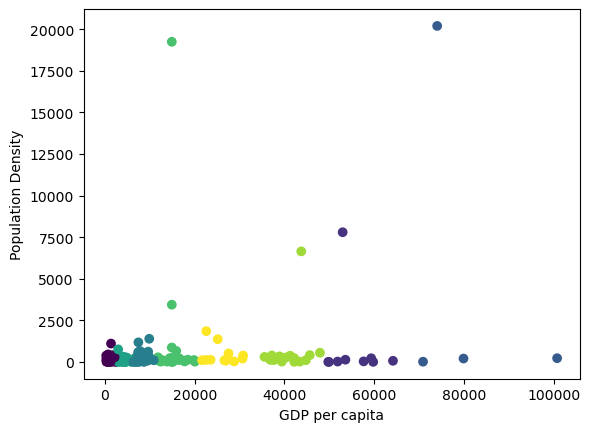

In [6]:
import matplotlib.pyplot as plt

plt.xlabel('GDP per capita')
plt.ylabel('Population Density')
plt.scatter(df[['GDP per capita']], df[['Population Density']], c=kmeansOne.labels_)
plt.show()

<a name="task2"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task2">Завдання  #2: </h2>

<p>Використайте метод ліктя для підбору оптимальної кількості кластерів.</p>
</div>


Визначаю оптимальну кількість кластерів. Скористаюсь методом "ліктя". Для цього ініціалізую алгоритм k середніх кількістю кластерів від 1 до 10 і для кожної моделі рахую суму квадратів похибок (евклідових відстаней точок кластерів від відповідних центрів):

In [ ]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(init='random', n_clusters=k, n_init=10, max_iter=300, random_state=42)
    kmeans.fit(features)
    wcss.append(kmeans.inertia_)

<p>Візуалізую отримані результати:</p>


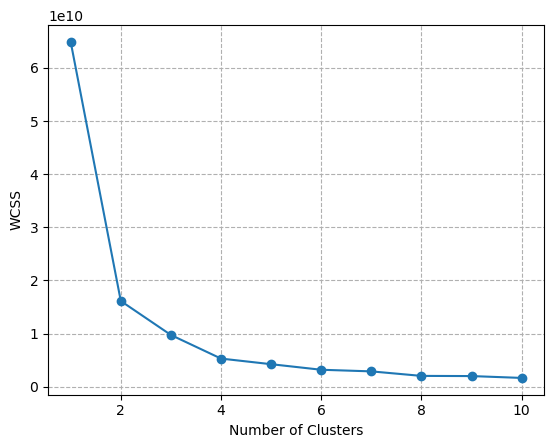

In [8]:
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(linestyle='--')
plt.show()

<p>Оптимальна кількість кластерів дорівнює: <strong>4</strong></p>
<p>Візуалізую для оптимальної кількості кластерів:</p>

d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


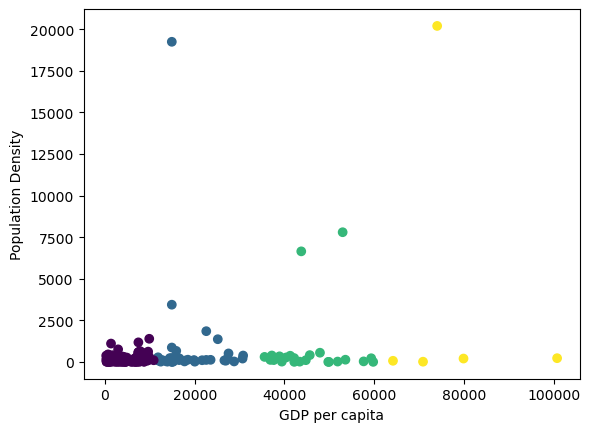

In [9]:
kmeansOptimal = KMeans(init='random', n_clusters=4, n_init=10, max_iter=300, random_state=42)
kmeansOptimal.fit(features)

plt.xlabel('GDP per capita')
plt.ylabel('Population Density')
plt.scatter(df[['GDP per capita']], df[['Population Density']], c=kmeansOptimal.labels_)
plt.show()

<a name="task3"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task3">Завдання  #3: </h2>

<p>Визначіть, який регіон домінує в кожному з кластерів.</p>
</div>


Додаю мітки кластерів в датафрейм

In [10]:
df['cluster'] = kmeansOptimal.labels_
df.head()

,Unnamed: 0,Country Name,Region,GDP per capita,Population,CO2 emission,Area,Population Density,cluster
0,0,Afghanistan,South Asia,561.778746,34656032.0,9809.225,652860.0,53.083405,0
1,1,Albania,Europe & Central Asia,4124.982390,2876101.0,5716.853,28750.0,100.038296,0
2,2,Algeria,Middle East & North Africa,3916.881571,40606052.0,145400.217,2381740.0,17.048902,0
3,3,American Samoa,East Asia & Pacific,11834.745230,55599.0,6501.591,200.0,277.995000,1
4,4,Andorra,Europe & Central Asia,36988.622030,77281.0,462.042,470.0,164.427660,2


Визначаю домінуючий регіон для кожного кластера

In [11]:
result = df.groupby('cluster')['Region'].agg(lambda x: x.value_counts().index[0])

for name in result.values:
    print(name)

Sub-Saharan Africa
Europe & Central Asia
Europe & Central Asia
Europe & Central Asia


<a name="task4"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task4">Завдання  #4: </h2>

<p>Побудуйте кілька (3-5) моделей класифікації, що визначають регіон, до якого належить країна, по ознаках 'GDP per capita', 'Population', 'CO2 emission', 'Area'. Оцініть точність класифікації (використайте 20% загального набору в якості тестових даних).</p>
</div>


 Обираю потрібні ознаки:


In [12]:
X = df[['GDP per capita', 'Population', 'CO2 emission', 'Area']]
y = df['Region']

 Розділяю дані на навчальну і тестову вибірки за допомогою функції <code>train_test_split()</code>:


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train)
print("Training set size:", len(X_train))
print('==' * 30)
print(X_test)
print("Testing set size:", len(X_test))

     GDP per capita  Population  CO2 emission      Area
84      2361.160205   9112867.0      9471.861  112490.0
95     30661.221810  60600590.0    320411.459  301340.0
137     7821.298918     13049.0        47.671      20.0
212     7456.658934    102951.0      5881.868     350.0
86     12820.088200   9817958.0     42086.159   93030.0
..              ...         ...           ...       ...
106     1077.603082   6082700.0      9607.540  199949.0
14     22579.093420   1425171.0     31338.182     771.0
92     64175.438240   4773095.0     34066.430   70280.0
179     3909.989066  21203000.0     18393.672   65610.0
102     4631.741283  25368620.0     40527.684  120540.0

[173 rows x 4 columns]
Training set size: 173
     GDP per capita   Population  CO2 emission       Area
205    40367.037840   65637239.0    419820.162   243610.0
214      990.334774   27584213.0     22698.730   527970.0
138      729.122251   28982771.0      8030.730   147180.0
177      952.768323   12230730.0      1496.136   

<h3>Навчання та тестування моделей:</h3>

Для навчання були обрані наступні методи:

- k-nearest neighbors;
- Decision Tree;
- Random Forest;
- Gradient Boosting;
- Support vector machines.

 <h3>k-nearest neighbors</h3>


Будую модель


In [14]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


Оцінюю точність

In [15]:
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix
print(classification_report(y_test, knn.predict(X_test)))
print('N-Nearest Neighbors Accuracy:', knn.score(X_test, y_test))

                            precision    recall  f1-score   support

       East Asia & Pacific       0.00      0.00      0.00         5
     Europe & Central Asia       0.42      0.36      0.38        14
 Latin America & Caribbean       0.17      0.12      0.14         8
Middle East & North Africa       0.00      0.00      0.00         3
             North America       0.00      0.00      0.00         1
                South Asia       0.00      0.00      0.00         2
        Sub-Saharan Africa       0.40      0.55      0.46        11

                  accuracy                           0.27        44
                 macro avg       0.14      0.15      0.14        44
              weighted avg       0.26      0.27      0.26        44

N-Nearest Neighbors Accuracy: 0.2727272727272727


d:\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [16]:
import seaborn as sns

def show_confusion_matrix(matrix, title):
    ax = sns.heatmap(matrix, annot=True, cmap='Greens')
    ax.set_title(title)
    ax.set_xlabel('\nPredicted Values')
    ax.set_ylabel('Actual Values ')
    plt.show()

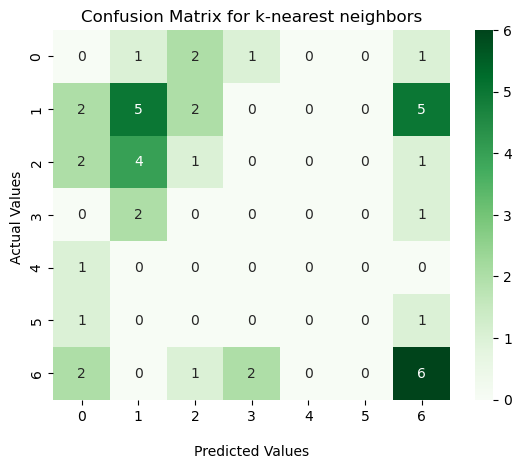

In [17]:
matrix = confusion_matrix(y_test, knn.predict(X_test))
show_confusion_matrix(matrix, 'Confusion Matrix for k-nearest neighbors')

 <h3>Decision Tree</h3>


Будую модель


In [18]:
from sklearn.tree import DecisionTreeClassifier
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Оцінюю точність

In [19]:
print('Decision Tree Accuracy:', decision_tree.score(X_test, y_test))

Decision Tree Accuracy: 0.4318181818181818


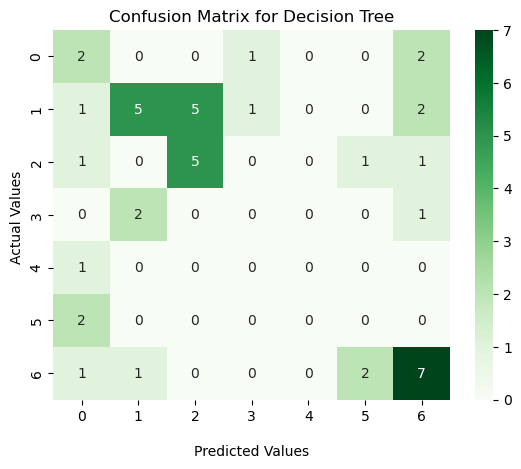

In [20]:
matrix = confusion_matrix(y_test, decision_tree.predict(X_test))
show_confusion_matrix(matrix, 'Confusion Matrix for Decision Tree')

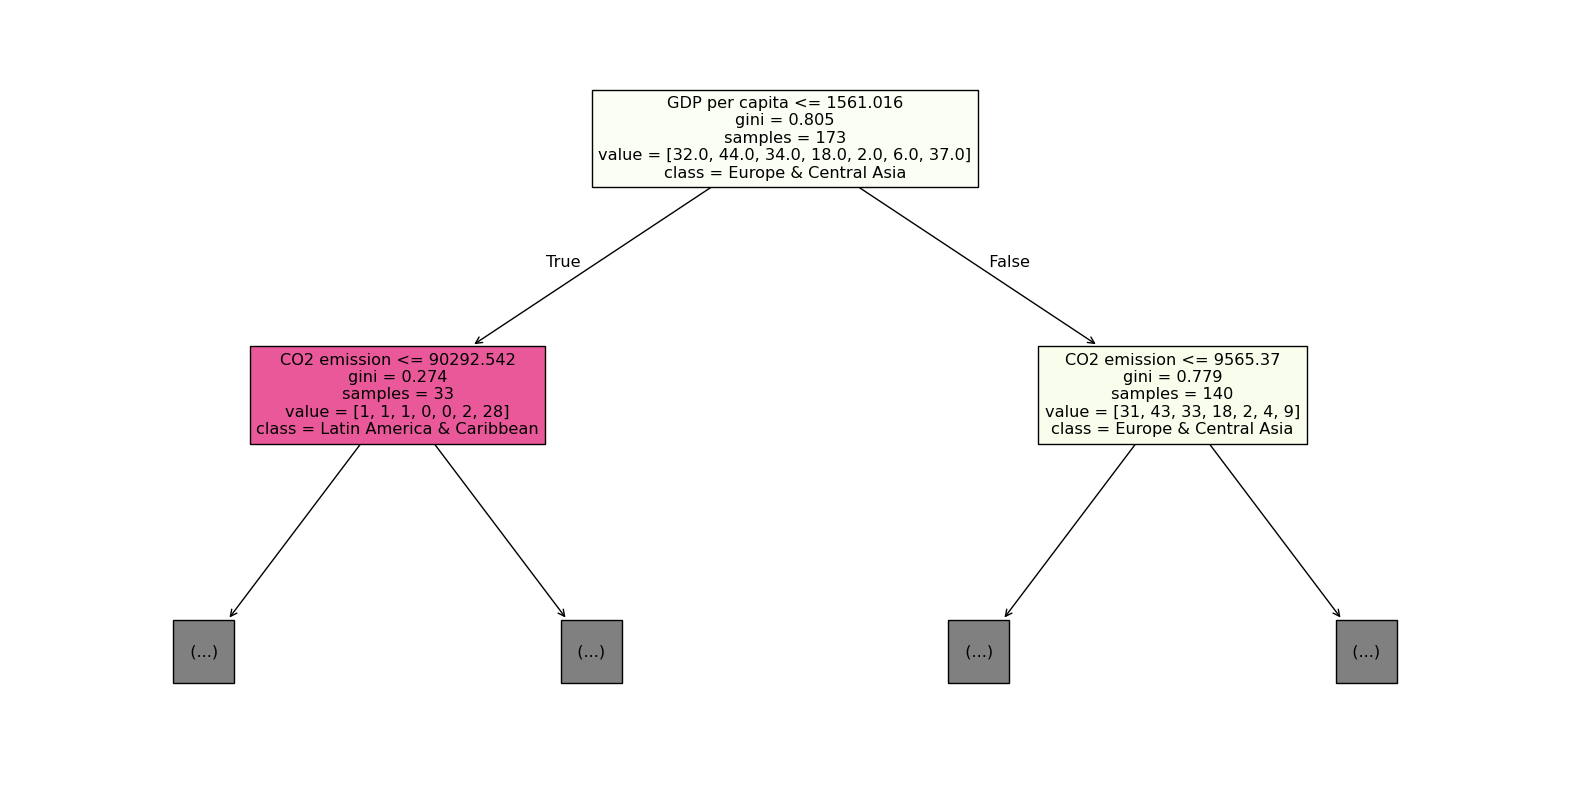

In [21]:
from sklearn import tree
plt.figure(figsize=(20,10))

tree.plot_tree(
    decision_tree,
    filled=True,
    feature_names=X_train.columns,
    class_names=y_train,
    max_depth=1 # протос подивтися на перший рівень дерева
)

plt.show()

 <h3>Random Forest</h3>


Будую модель


In [22]:
from sklearn.ensemble import RandomForestClassifier
random_forest = RandomForestClassifier(max_depth=5)
random_forest.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Оцінюю точність

In [23]:
print('Random Forest Accuracy:', random_forest.score(X_test, y_test))

Random Forest Accuracy: 0.5909090909090909


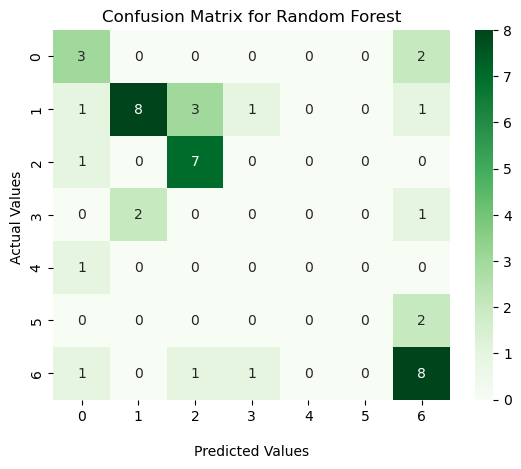

In [24]:
matrix = confusion_matrix(y_test, random_forest.predict(X_test))
show_confusion_matrix(matrix, 'Confusion Matrix for Random Forest')

In [25]:
importances = random_forest.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(feature_importance_df)

          feature  importance
0  GDP per capita    0.403985
2    CO2 emission    0.228316
1      Population    0.190758
3            Area    0.176941


 <h3>Gradient Boosting</h3>


Будую модель


In [26]:
from sklearn.ensemble import GradientBoostingClassifier
gradboost = GradientBoostingClassifier(learning_rate=0.05) 
gradboost.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.05
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


Оцінюю точність

In [27]:
print('Gradient Boosting Accuracy:', gradboost.score(X_test, y_test))

Gradient Boosting Accuracy: 0.6136363636363636


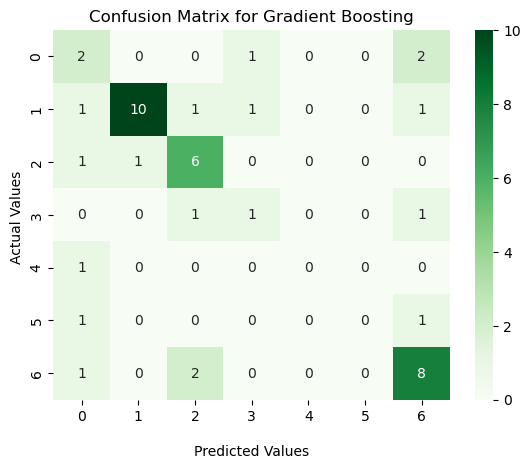

In [28]:
matrix = confusion_matrix(y_test, gradboost.predict(X_test))
show_confusion_matrix(matrix, 'Confusion Matrix for Gradient Boosting')

 <h3>Support vector machines</h3>


Будую модель


In [29]:
from sklearn.svm import SVC
SVC_model = SVC()
SVC_model.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


Оцінюю точність

In [30]:
print('Support Vector Machine Accuracy:', SVC_model.score(X_test, y_test))

Support Vector Machine Accuracy: 0.3181818181818182


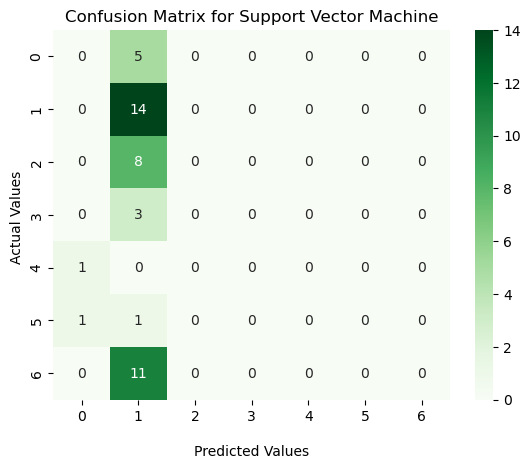

In [31]:
matrix = confusion_matrix(y_test, SVC_model.predict(X_test))
show_confusion_matrix(matrix, 'Confusion Matrix for Support Vector Machine')

<h4>Висновок</h4>
<p>Порівнюючи всі моделі, роблю висновок, що <b>модель Random Forest є найкращою</b>, оскільки вона показала найвищу точність (Accuracy: 0.6364) серед розглянутих підходів.</p>

<a name="task5"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task5">Завдання  #5: </h2>

<p>Для однієї з моделей виконайте підбір параметра. Обгрунтуйте ваш вибір.</p>
</div>


<p>Скористаюсь методом "ліктя" для визначення параметра max_depth методу Random Forest</p>
<p>Для цього ініціалізую алгоритм з параметром від 1 до 20 (глубини) і для кожної моделі порахую помилку на тренувальній та валідаційній вибірках:</p>

In [32]:
from sklearn.metrics import accuracy_score

depths = range(1, 21)

train_errors = []
val_errors = []

for depth in depths:
    model = RandomForestClassifier(
        max_depth=depth,
        n_estimators=100,
        random_state=42
    )
    
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_test)
    
    train_error = 1 - accuracy_score(y_train, y_train_pred)
    val_error = 1 - accuracy_score(y_test, y_val_pred)
    
    train_errors.append(train_error)
    val_errors.append(val_error)


 Отримані показники якості візуалізую на графіку:


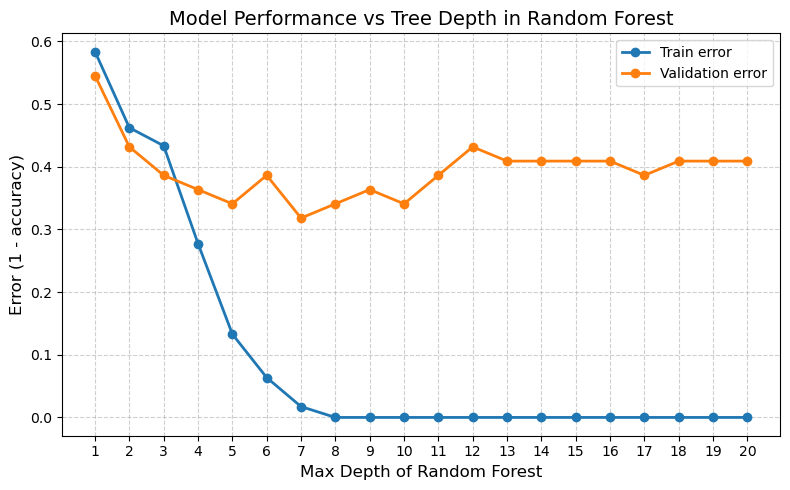

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(depths, train_errors, marker='o', linewidth=2, label="Train error")
plt.plot(depths, val_errors, marker='o', linewidth=2, label="Validation error")

plt.xlabel("Max Depth of Random Forest", fontsize=12)
plt.ylabel("Error (1 - accuracy)", fontsize=12)
plt.title("Model Performance vs Tree Depth in Random Forest", fontsize=14)

plt.xticks(depths)
plt.grid(True, linestyle="--", alpha=0.6)

plt.legend()
plt.tight_layout()
plt.show()

З графіку бачу, що найкраще значення параметра глубини знаходиться в межах від 6 до 7, тому що саме в цьому діапазоні помилка досягає свого мінімуму (≈ 0.32), а подальше збільшення глибини дерева призводить до overfitting  - train error прямує до 0, тоді як validation error зростає назад до ≈ 0.40 і більше. 

<a name="task6"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task6"> Додаткове завдання: </h2>

<p>Використовуючи файл <a href="https://drive.google.com/file/d/1gxqzPQNlqrwrJI3zstMsvHQAbsdMPe-2/view?usp=drive_link" target="_blank">Data5.csv</a>:

1. Визначити кластер країн з найкращим розвитком (кластеризувати по Ie, Iec, Is; для k-середніх використати 4 кластера). Побудувати центри кластерів.
2. Провести кластеризацію по Сql, порахувати скільки країн потрапило в різні кластери, якщо порівнювати з п1.</p>
</div>


Згідно з методологією вимірювання сталого розвитку країн, сталий розвиток оцінюється за допомогою відповідного індексу у просторі трьох вимірів: економічного (Іес), екологічного (Іе) і соціально-інституціонального (Is). Цей індекс є вектором, норма якого визначає рівень сталого розвитку, а його просторове положення в системі координат (Iec,Ie,Is) характеризує міру «гармонійності» цього розвитку.

<details><summary>Натисніть тут, щоб побачити підказку до першого завдання</summary>

```python
# Зчитуємо заданий набір даних, зразу коригуючи
df = pd.read_csv(
    'Data5.csv', encoding='windows-1251', sep=';', decimal=','
).rename(columns={'Unnamed: 0': 'Country'})

df

```

</details>



In [34]:
file_name = 'Data5.csv'
df2 = pd.read_csv(file_name, encoding='windows-1251', sep=';', decimal=',').rename(columns={'Unnamed: 0': 'Country'})
df2.head()

,Country,ISO,UA,Cql,Ie,Iec,Is
0,Albania,ALB,Албанія,0.973924,0.605348,0.538673,0.510113
1,Algeria,DZA,Алжир,0.782134,0.587219,0.348159,0.497986
2,Angola,AGO,Ангола,0.372344,0.274394,0.332117,0.346907
3,Argentina,ARG,Аргентина,0.883830,0.699685,0.281995,0.518820
4,Armenia,ARM,Вірменія,1.016499,0.718327,0.535648,0.486498


<details><summary>Натисніть тут, щоб побачити підказку до другого завдання</summary>

Номери кластерів для першого і другого методів кластеризації зовсім не обовязково співпадатимуть. Щоб знайти відповідність, подивіться в які кластери з другого методу потрапляють центри кластерів з першого.

Порахувати скільки країн потрапило в різні кластери можна з використанням матриці невідповідностей (як аргументи поставти номери кластерів для першого і другого методів кластеризації).

</details>

<h3> Завдання 1: кластеризація по Ie, Iec, Is </h3>

In [35]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D

# le - економічний індекс
# lec - індекс економічного розвитку
# ls - соціально-інституційний індекс
# вектор (Ie, Iec, Is) -> загальний рівень розвитку

features = df2[['Iec', 'Ie', 'Is']]

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

kmeans3 = KMeans(init='k-means++', n_clusters=4, n_init=10, max_iter=300, random_state=42)
kmeans3.fit(features_scaled)

df2['cluster_1'] = kmeans3.labels_

centers = kmeans3.cluster_centers_
print("Cluster Centers:")
print(centers)

Cluster Centers:
[[ 0.42412431  0.44457367  0.47193764]
 [-0.8933883  -1.47090611 -1.20075561]
 [ 1.4754733   1.06446185  1.40995615]
 [-0.61859247  0.03180168 -0.39719217]]


d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [36]:
norms = np.linalg.norm(centers, axis=1)
best_cluster = np.argmax(norms)
print("Best Cluster Index:", best_cluster)

Best Cluster Index: 2


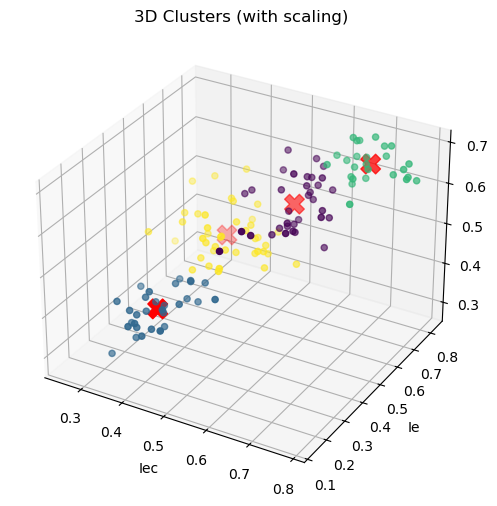

In [37]:
from mpl_toolkits.mplot3d import Axes3D

centers_original = scaler.inverse_transform(centers)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df2['Iec'], df2['Ie'], df2['Is'], c=df2['cluster_1'])
ax.scatter(centers_original[:, 0], centers_original[:, 1], centers_original[:, 2], s=200, marker='X', c='red')

ax.set_xlabel('Iec')
ax.set_ylabel('Ie')
ax.set_zlabel('Is')

plt.title('3D Clusters (with scaling)')
plt.show()

<h3> Завдання 2: кластеризація по Сql </h3>

In [38]:
features2 = df2[['Cql']]

kmeans4 = KMeans(
    init='k-means++',
    n_clusters=4,
    n_init=10,
    max_iter=300,
    random_state=42
)

kmeans4.fit(features2)

df2['cluster_2'] = kmeans4.labels_

d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


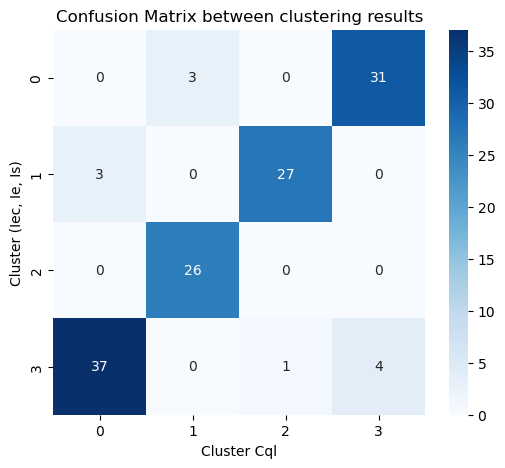

In [39]:
conf_matrix = confusion_matrix(df2['cluster_1'], df2['cluster_2'])

plt.figure(figsize=(6,5))

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Cluster Cql")
plt.ylabel("Cluster (Iec, Ie, Is)")
plt.title("Confusion Matrix between clustering results")

plt.show()

Підсумовуючи, можна сказати, що матриця показує часткову відповідність між кластеризацією за (Iec, Ie, Is) та індексом Cql: деякі кластери мають чіткі відповідності, однак значна частина країн розподіляється між різними групами. Це свідчить, що Cql лише частково відтворює структуру багатовимірної моделі розвитку.

<h2>Виконав студент групи ІП-45 <br>Буряк Володимир</h2>
